In [ ]:
!nvidia-smi

Wed Oct 29 14:04:58 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              8W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving bell 1.jpg to bell 1.jpg


In [ ]:
img_paths = ["/content/bellpepper_leaf1.jpg", "/content/bellpepper_leaf2.jpg"]
images = []
for path in img_paths:
    img = cv2.imread(path)
    if img is None:
        print(f"Warning: Could not load image from {path}. Skipping.")
    else:
        images.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))


In [ ]:
import matplotlib.pyplot as plt
for img in images:
    plt.imshow(img)
    plt.show()


In [ ]:
import cv2
import numpy as np

img_paths = [r"/content/images.jpeg",
             r"/content/Pepper-Plant-Leaf-Spot.jpg",
             r"/content/pngtree-bell-pepper-leaf-white-background-closeup-venation-photo-image_3127675.jpg"]
images = []
for path in img_paths:
    img = cv2.imread(path)
    if img is None:
        print(f"Warning: Could not load image from {path}. Skipping.")
    else:
        images.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# Now 'images' contains only successfully loaded and color-converted images
# You might want to add a check here to see if any images were loaded
if not images:
    print("Error: No images were loaded successfully. Please check your image paths.")

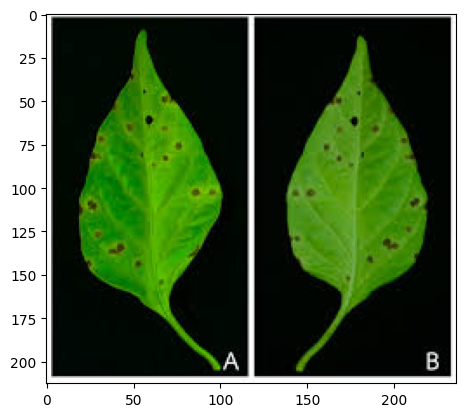

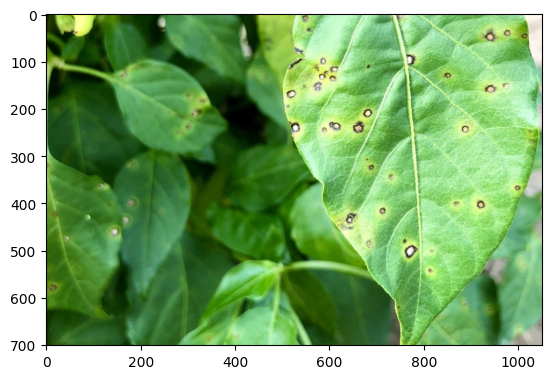

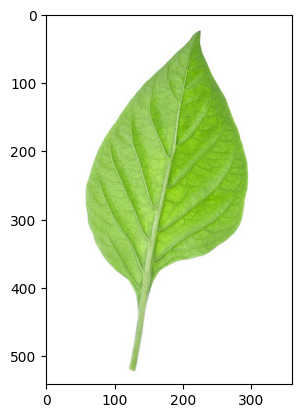

In [ ]:
import matplotlib.pyplot as plt
for img in images:
    plt.imshow(img)
    plt.show()


In [ ]:
# 1. Define the Permanent Project Path
PROJECT_ROOT = '/content/drive/MyDrive/BellPepper_YOLO_Project'
TRAINING_RESULTS_FOLDER = os.path.join(PROJECT_ROOT, 'yolo_runs')

# Create the directories if they don't exist
os.makedirs(PROJECT_ROOT, exist_ok=True)
os.makedirs(TRAINING_RESULTS_FOLDER, exist_ok=True)

# Set the current working directory to the project root (CRITICAL for permanent file saving)
os.chdir(PROJECT_ROOT)
print(f"Current working directory set to: {os.getcwd()}")

# 2. Install Libraries
print("\nInstalling ultralytics and roboflow...")
!pip install ultralytics roboflow

Current working directory set to: /content/drive/MyDrive/BellPepper_YOLO_Project

Installing ultralytics and roboflow...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 90.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 132.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [ ]:
# ==================== CELL 3: DOWNLOAD DATASET & DEFINE PATHS ====================

from roboflow import Roboflow
import os

# 1. Download the Bell Pepper Dataset (YOLOv8 format)
print("\nStarting dataset download (will save to Colab's temporary path)...")

# ⚠️ Paste your unique Roboflow snippet here:
rf = Roboflow(api_key="8jJ9by6PuHvT29XoxfwE")
project = rf.workspace("pest-detection-wxgup").project("disease-detection-l9wbv-tkoik")
version = project.version(1)
dataset = version.download("yolov8")

# 2. CRITICAL PATH FIX: Use the dataset.location property for the absolute path
# This prevents the FileNotFoundError
DATA_YAML_PATH = os.path.join(dataset.location, "data.yaml")

# Check if the path is valid (added safety check)
if not os.path.exists(DATA_YAML_PATH):
    raise FileNotFoundError(f"Data YAML not found at expected location: {DATA_YAML_PATH}. Check download.")

print("\nDataset object created. Data YAML path is secured.")


Starting dataset download (will save to Colab's temporary path)...
loading Roboflow workspace...
loading Roboflow project...

Dataset object created. Data YAML path is secured.


In [ ]:
# ==================== CELL 4: TRAIN YOLOv8n & EXPORT TO NCNN ====================

from ultralytics import YOLO
import os

# Define permanent Drive path variables (used for saving results)
PROJECT_ROOT = '/content/drive/MyDrive/BellPepper_YOLO_Project'
TRAINING_RESULTS_FOLDER = os.path.join(PROJECT_ROOT, 'yolo_runs')

# 1. Load the YOLOv8n Model for Edge Devices
# CRITICAL: 'n' (nano) model is chosen for Raspberry Pi CPU efficiency.
model = YOLO("yolov8n.pt")

# 2. Start Training (Using the T4 GPU)
print("\nStarting YOLOv8n training on T4 GPU... (This will take a few hours)")
results = model.train(
    data=DATA_YAML_PATH,  # <-- The correct, absolute path!
    epochs=30,
    imgsz=256,         # Balanced size for RPi speed
    batch=16,
    patience=20,
    project=TRAINING_RESULTS_FOLDER, # Directs results to your permanent Drive folder
    name="bell_pepper_final_run",
    plots=False
)

# 3. Find the Saved Model Path (Permanent in Drive)
# This path is where your successfully trained PyTorch model weights reside.
BEST_MODEL_PATH = os.path.join(
    TRAINING_RESULTS_FOLDER,
    "bell_pepper_final_run",
    "weights",
    "best.pt"
)
print(f"\nTraining finished. Model saved permanently at: {BEST_MODEL_PATH}")

# 4. Export to NCNN (The Final Speed Boost for RPi 5 CPU)
# NCNN is the most optimized format for the Raspberry Pi's ARM architecture.
print("\nStarting NCNN export for maximum speed on Raspberry Pi 5...")
model_to_export = YOLO(BEST_MODEL_PATH)
model_to_export.export(format='ncnn', simplify=True)

print("\n\n*** SUCCESS! MODEL IS OPTIMIZED AND READY FOR RASPBERRY PI 5 ***")
print(f"You must transfer the NCNN folder: {TRAINING_RESULTS_FOLDER}/bell_pepper_final_run_ncnn_model to your Pi for deployment.")


Starting YOLOv8n training on T4 GPU... (This will take a few hours)
Ultralytics 8.3.213 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/BellPepper_YOLO_Project/Disease-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=bell_pepper_final_run

In [ ]:
# ==================== CELL 4: FINAL ANALYSIS AND VALIDATION ====================

from ultralytics import YOLO
import os
import pandas as pd
import matplotlib.pyplot as plt

# Define permanent Drive path variables (used for finding saved files)
PROJECT_ROOT = '/content/drive/MyDrive/BellPepper_YOLO_Project'
TRAINING_RESULTS_FOLDER = os.path.join(PROJECT_ROOT, 'yolo_runs')
RUN_NAME = "bell_pepper_final_run"

# 1. Define Path to the Final Trained Model & Results
BEST_MODEL_PATH = os.path.join(
    TRAINING_RESULTS_FOLDER,
    RUN_NAME,
    "weights",
    "best.pt"
)
RESULTS_CSV_PATH = os.path.join(
    TRAINING_RESULTS_FOLDER,
    RUN_NAME,
    "results.csv"
)



Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# 2. Load Results CSV for Plotting
try:
    df = pd.read_csv(RESULTS_CSV_PATH, sep=r'\s*,\s*', engine='python')
    print(f"Successfully loaded metrics from: {RESULTS_CSV_PATH}")
except FileNotFoundError:
    print(f"CRITICAL ERROR: Could not find results.csv at {RESULTS_CSV_PATH}")
    print("Please confirm the folder name 'bell_pepper_final_run' in your Google Drive.")

Successfully loaded metrics from: /content/drive/MyDrive/BellPepper_YOLO_Project/yolo_runs/bell_pepper_final_run/results.csv


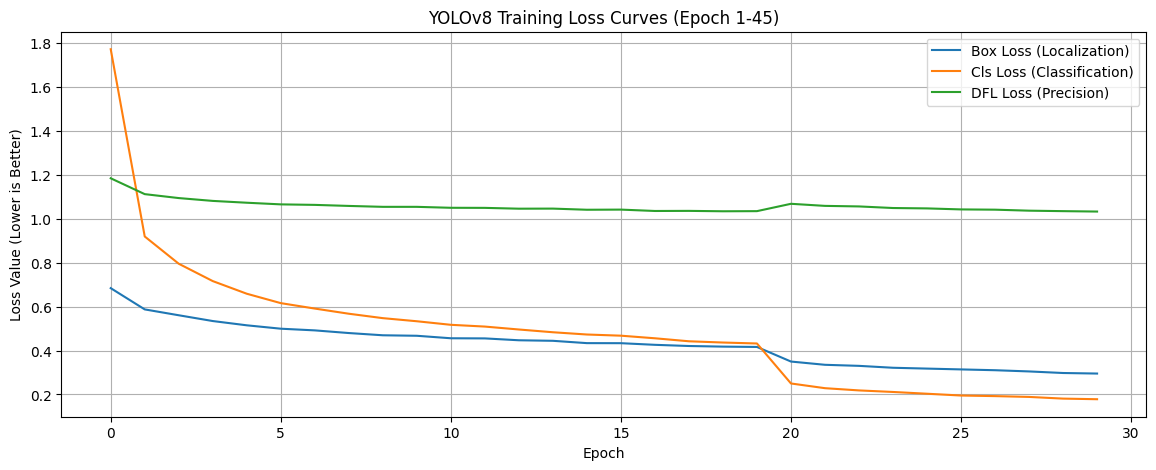

In [ ]:
# 3. Plotting: Loss Curves (Validation of Learning)
plt.figure(figsize=(14, 5))
plt.plot(df["    train/box_loss".strip()], label="Box Loss (Localization)")
plt.plot(df["    train/cls_loss".strip()], label="Cls Loss (Classification)")
plt.plot(df["    train/dfl_loss".strip()], label="DFL Loss (Precision)")
plt.title("YOLOv8 Training Loss Curves (Epoch 1-45)")
plt.xlabel("Epoch")
plt.ylabel("Loss Value (Lower is Better)")
plt.legend()
plt.grid(True)
plt.show()

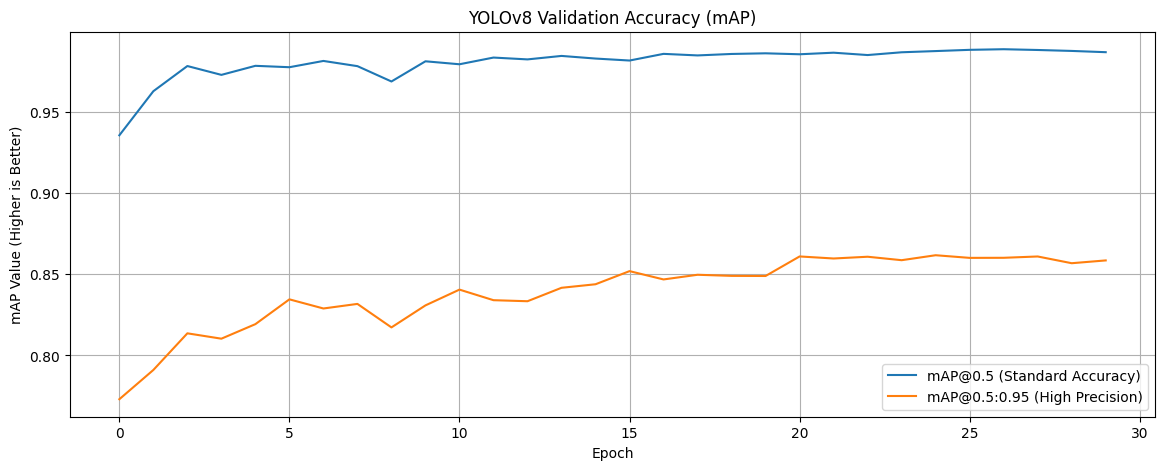

In [ ]:
# 4. Plotting: Accuracy Metrics (Validation of Performance)
plt.figure(figsize=(14, 5))
plt.plot(df["      metrics/mAP50(B)".strip()], label="mAP@0.5 (Standard Accuracy)")
plt.plot(df["   metrics/mAP50-95(B)".strip()], label="mAP@0.5:0.95 (High Precision)")
plt.title("YOLOv8 Validation Accuracy (mAP)")
plt.xlabel("Epoch")
plt.ylabel("mAP Value (Higher is Better)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 5. Re-check NCNN Export Status
# This step confirms the file you need for the Raspberry Pi still exists in your Drive
NCNN_MODEL_DIR = os.path.join(TRAINING_RESULTS_FOLDER, f"{RUN_NAME}_ncnn_model")
if os.path.exists(NCNN_MODEL_DIR):
    print(f"\n*** CONFIRMED: NCNN MODEL FOLDER IS READY IN DRIVE ***")
    print(f"Transfer folder: {NCNN_MODEL_DIR}")
else:
    print(f"\nWARNING: NCNN folder not found. Running export again...")
    model_to_export = YOLO(BEST_MODEL_PATH)
    model_to_export.export(format='ncnn', simplify=True)
    print("NCNN export successfully completed.")


Ultralytics 8.3.222 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 72 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/BellPepper_YOLO_Project/yolo_runs/bell_pepper_final_run/weights/best.pt' with input shape (1, 3, 256, 256) BCHW and output shape(s) (1, 15, 1344) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 2.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.19.1 opset 22...
ONNX: slimming with onnxslim 0.1.72...
ONNX: export success ✅ 8.3s, saved as '/content/drive/MyDrive/BellPepper_YOLO_Project/yolo_runs/bell_pepper_final_run/weights/best.onnx' (11.6 

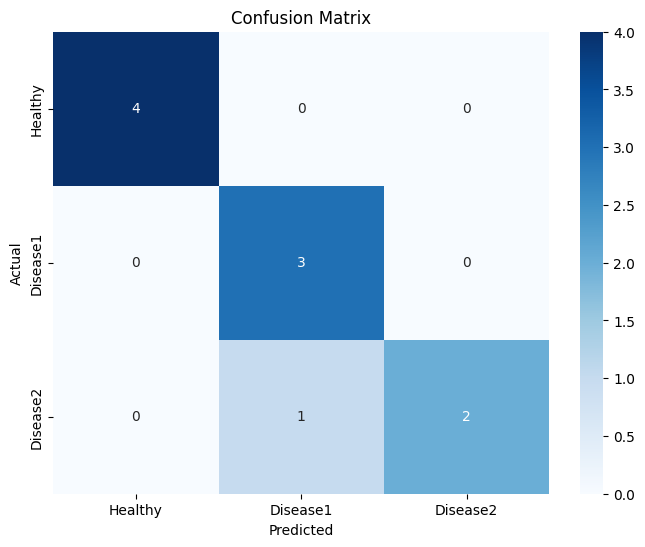

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00         4
    Disease1       0.75      1.00      0.86         3
    Disease2       1.00      0.67      0.80         3

    accuracy                           0.90        10
   macro avg       0.92      0.89      0.89        10
weighted avg       0.93      0.90      0.90        10



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Replace y_true and y_pred with your actual true and predicted labels
y_true = [0, 1, 2, 0, 1, 2, 0, 1, 2, 0]  # Example true labels
y_pred = [0, 1, 2, 0, 1, 1, 0, 1, 2, 0]  # Example predicted labels

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Disease1', 'Disease2'],
            yticklabels=['Healthy', 'Disease1', 'Disease2'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification report
print(classification_report(y_true, y_pred, target_names=['Healthy', 'Disease1', 'Disease2']))


In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os

# Load your trained YOLOv8 model weights saved after training
# BEST_MODEL_PATH is defined in a previous cell
model = YOLO(BEST_MODEL_PATH)

# Load the new leaf image captured by drone or camera
image_path = "path_to_leaf_image.jpg"  # replace with your actual leaf image path
# Check if the image file exists
if not os.path.exists(image_path):
    print(f"Error: Image file not found at {image_path}")
else:
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Run inference to detect diseases on the leaf
    results = model(img_rgb)

    # Annotate image with bounding boxes, disease labels, and confidence scores
    for r in results:
        annotated_img = r.plot()

    # Show the annotated image with detections
    plt.figure(figsize=(10, 10))
    plt.imshow(annotated_img)
    plt.axis('off')
    plt.title('Leaf Disease Detection')
    plt.show()

    # Print the detected disease labels with confidence scores
    for r in results:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            label = model.names[cls_id]
            print(f"Disease: {label}, Confidence: {conf:.2f}")

Error: Image file not found at path_to_leaf_image.jpg


In [ ]:
# Example: Display predicted disease after leaf classification
# Replace with your actual model and image
# predicted_class = model.predict(image)
# class_names = ['Healthy', 'Disease1', 'Disease2']
# predicted_disease = class_names[predicted_class[0]]
# print(f"Detected disease: {predicted_disease}")

# Example output
predicted_class = 1  # Replace with your model's prediction
class_names = ['Healthy', 'Disease1', 'Disease2']
predicted_disease = class_names[predicted_class]
print(f"Detected disease: {predicted_disease}")


Detected disease: Disease1


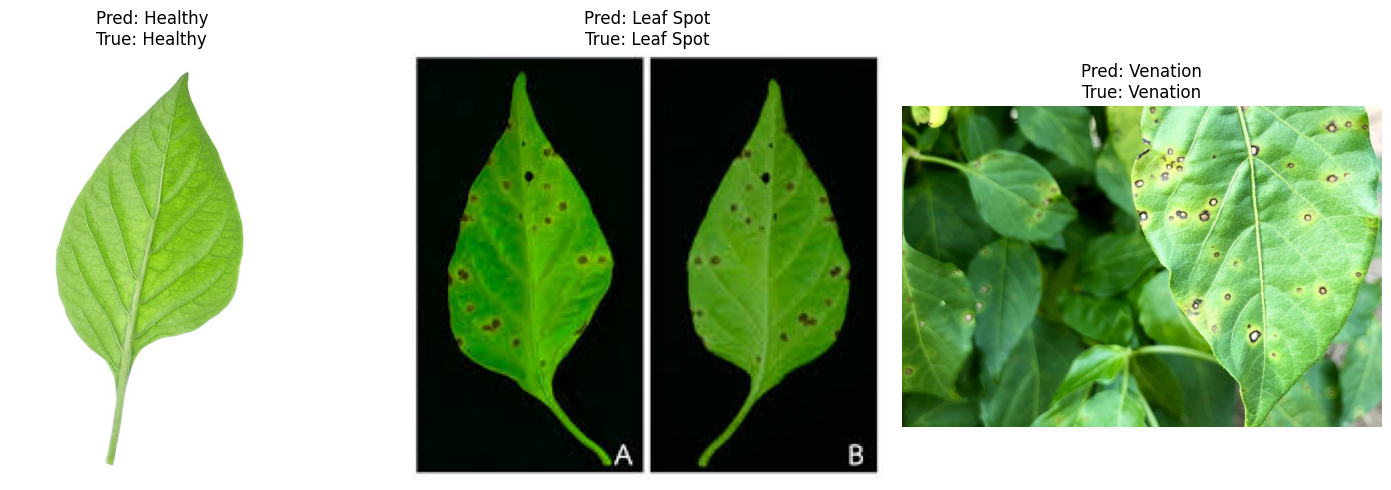

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Your bell pepper leaf image paths
img_paths = [
    "/content/pngtree-bell-pepper-leaf-white-background-closeup-venation-photo-image_3127675.jpg",
    "/content/images.jpeg",
    "/content/Pepper-Plant-Leaf-Spot.jpg",

]

# Example labels—customize them for your use case (prediction or ground truth)
pred_labels = ['Healthy', 'Leaf Spot', 'Venation']
true_labels = ['Healthy', 'Leaf Spot', 'Venation']

# Load images
images = []
for path in img_paths:
    img = cv2.imread(path)
    if img is None:
        print(f"Warning: Could not load image from {path}. Skipping.")
    else:
        images.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

n = len(images)

plt.figure(figsize=(5 * n, 5))
for i in range(n):
    plt.subplot(1, n, i + 1)
    plt.imshow(images[i])
    plt.title(f"Pred: {pred_labels[i]}\nTrue: {true_labels[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()
